In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'VGG19'
MODEL_NAME

'VGG19'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for VGG19 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics (Required for VGG19 weights)
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class VGG19(nn.Module):
    """
    VGG19-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: VGG19 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained VGG19
        weights = models.VGG19_Weights.IMAGENET1K_V1
        backbone = models.vgg19(weights=weights)

        # VGG19 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 512, H, W) -> (Batch, 512, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 512, 1, 1) -> (Batch, 512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=512, out_features=num_classes) # VGG19 features output exactly 512 channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [11]:
def build_vgg19(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> VGG19:
    """
    Factory function to instantiate the customized VGG19 model for Transfer Learning.

    This function initializes a `VGG19` which includes:
    1. A frozen VGG19 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        VGG19Classifier: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = VGG19(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the VGG19 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-3.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_vgg19().to(device=device)

    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_vgg19().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 6)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of VGG19 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of VGG19 (torchvision) Feature Indices:
    - Block 5 starts at index 28
    - Block 4 starts at index 19
    - Block 3 starts at index 10
    - Block 2 starts at index 5
    - Block 1 starts at index 0

    Args:
        model (nn.Module): The VGG19 model instance.
        block_num (int): The block number (1 to 5) from which to start training.
            - 5: Train only the last convolutional block and classifier.
            - 1: Train the entire network.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.features
    block_indices = {
        5: 28,
        4: 19,
        3: 10,
        2: 5,
        1: 0,
    }

    start_index = block_indices[block_num]

    # 1. Configure Backbone (Feature Extractor)
    # Iterate through all layers in the 'features' sequential module
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            # Unfreeze: Allow gradient updates for layers in this block and above
            for param in child.parameters():
                param.requires_grad = True
        else:
            # Freeze: Prevent gradient updates for lower layers to preserve learned features
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head
    # The classification head (Dense layers) must always be trainable during fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the VGG19 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features without destroying them.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The VGG block number to unfreeze (e.g., 5, 4, 3...).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to MODEL_NAME.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_vgg19().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    # Use the helper function to set requires_grad=True for the target block
    set_trainable_from_block(model=model, block_num=block)

    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific VGG block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    model = build_vgg19().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 6
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 228MB/s] 


Epoch 1/50 | loss: 0.4652 - accuracy: 0.4778 | val_loss: 0.4311 - val_accuracy: 0.5424
val_accuracy improved from 0.0000 to 0.5424, saving weights to /kaggle/working/VGG19_block_6_fold_1.pth


Epoch 2/50 | loss: 0.4250 - accuracy: 0.5508 | val_loss: 0.3972 - val_accuracy: 0.6052
val_accuracy improved from 0.5424 to 0.6052, saving weights to /kaggle/working/VGG19_block_6_fold_1.pth


Epoch 3/50 | loss: 0.3945 - accuracy: 0.5960 | val_loss: 0.3699 - val_accuracy: 0.6550
val_accuracy improved from 0.6052 to 0.6550, saving weights to /kaggle/working/VGG19_block_6_fold_1.pth


...

Epoch 25/50 | loss: 0.2039 - accuracy: 0.8002 | val_loss: 0.2003 - val_accuracy: 0.8063
val_accuracy did not improve from 0.8137


Epoch 26/50 | loss: 0.2075 - accuracy: 0.7910 | val_loss: 0.1969 - val_accuracy: 0.8026
val_accuracy did not improve from 0.8137


Epoch 27/50 | loss: 0.2045 - accuracy: 0.7930 | val_loss: 0.1922 - val_accuracy: 0.8118
val_accuracy did not improve from 0.8137


Epoch 28/50 | loss: 0.2040 - accuracy: 0.7815 | val_loss: 0.1939 - val_accuracy: 0.8063
val_accuracy did not improve from 0.8137


Epoch 29/50 | loss: 0.1988 - accuracy: 0.8049 | val_loss: 0.1923 - val_accuracy: 0.8063
val_accuracy did not improve from 0.8137
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.199999  0.813653
                  precision    recall  f1-score   support

    Glioma Tumor       0.76      0.95      0.85       245
Meningioma Tumor       0.71      0.60      0.65       112
 Pituitary Tumor       0.99      0.77      0.86       185

        accuracy                           0.81       542
       macro avg       0.82      0.77      0.79       542
    weighted avg       0.83      0.81      0.81       542



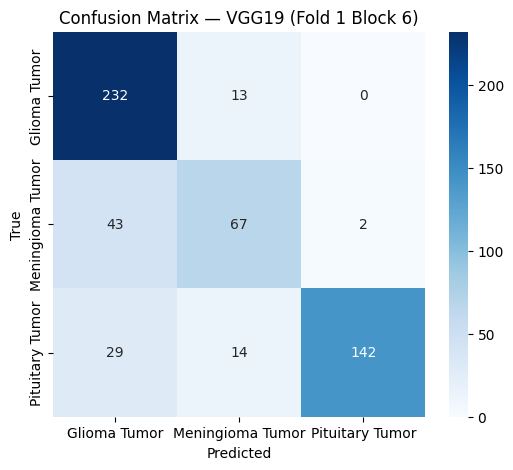

Fold: 1 block 5


Epoch 1/50 | loss: 0.1666 - accuracy: 0.8152 | val_loss: 0.1396 - val_accuracy: 0.8542
val_accuracy improved from 0.0000 to 0.8542, saving weights to /kaggle/working/VGG19_block_5_fold_1.pth


Epoch 2/50 | loss: 0.1386 - accuracy: 0.8422 | val_loss: 0.1800 - val_accuracy: 0.7915
val_accuracy did not improve from 0.8542


Epoch 3/50 | loss: 0.1110 - accuracy: 0.8692 | val_loss: 0.1406 - val_accuracy: 0.8358
val_accuracy did not improve from 0.8542


Epoch 4/50 | loss: 0.1035 - accuracy: 0.8771 | val_loss: 0.1157 - val_accuracy: 0.8727
val_accuracy improved from 0.8542 to 0.8727, saving weights to /kaggle/working/VGG19_block_5_fold_1.pth


...

Epoch 13/50 | loss: 0.0563 - accuracy: 0.9259 | val_loss: 0.0761 - val_accuracy: 0.9207
val_accuracy did not improve from 0.9244


Epoch 14/50 | loss: 0.0554 - accuracy: 0.9286 | val_loss: 0.0644 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9244


Epoch 15/50 | loss: 0.0512 - accuracy: 0.9393 | val_loss: 0.0795 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9244


Epoch 16/50 | loss: 0.0517 - accuracy: 0.9290 | val_loss: 0.0802 - val_accuracy: 0.9207
val_accuracy did not improve from 0.9244


Epoch 17/50 | loss: 0.0489 - accuracy: 0.9354 | val_loss: 0.0797 - val_accuracy: 0.9170
val_accuracy did not improve from 0.9244
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.078527  0.924354
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.96      0.96       245
Meningioma Tumor       0.77      0.92      0.84       112
 Pituitary Tumor       1.00      0.89      0.94       185

        accuracy                           0.92       542
       macro avg       0.91      0.92      0.91       542
    weighted avg       0.93      0.92      0.93       542



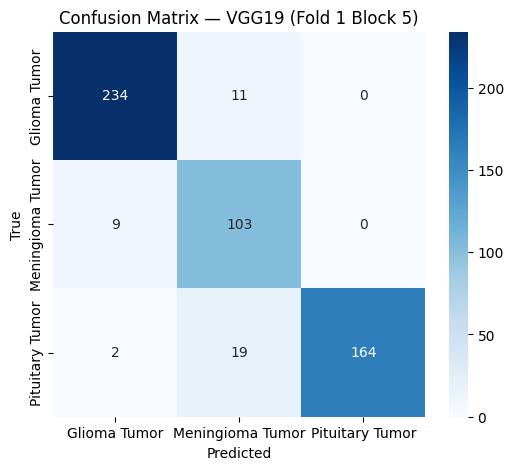

Fold: 1 block 4


Epoch 1/50 | loss: 0.0606 - accuracy: 0.9191 | val_loss: 0.1009 - val_accuracy: 0.8801
val_accuracy improved from 0.0000 to 0.8801, saving weights to /kaggle/working/VGG19_block_4_fold_1.pth


Epoch 2/50 | loss: 0.0545 - accuracy: 0.9350 | val_loss: 0.0703 - val_accuracy: 0.9262
val_accuracy improved from 0.8801 to 0.9262, saving weights to /kaggle/working/VGG19_block_4_fold_1.pth


Epoch 3/50 | loss: 0.0458 - accuracy: 0.9413 | val_loss: 0.0710 - val_accuracy: 0.9244
val_accuracy did not improve from 0.9262


Epoch 4/50 | loss: 0.0403 - accuracy: 0.9465 | val_loss: 0.0654 - val_accuracy: 0.9317
val_accuracy improved from 0.9262 to 0.9317, saving weights to /kaggle/working/VGG19_block_4_fold_1.pth


...

Epoch 9/50 | loss: 0.0215 - accuracy: 0.9699 | val_loss: 0.0790 - val_accuracy: 0.9151
val_accuracy did not improve from 0.9373


Epoch 10/50 | loss: 0.0216 - accuracy: 0.9695 | val_loss: 0.1265 - val_accuracy: 0.8948
val_accuracy did not improve from 0.9373


Epoch 11/50 | loss: 0.0249 - accuracy: 0.9687 | val_loss: 0.0984 - val_accuracy: 0.9077
val_accuracy did not improve from 0.9373


Epoch 12/50 | loss: 0.0157 - accuracy: 0.9802 | val_loss: 0.0633 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9373


Epoch 13/50 | loss: 0.0155 - accuracy: 0.9802 | val_loss: 0.0765 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9373
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG19  0.05833  0.937269
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.96      0.96       245
Meningioma Tumor       0.82      0.91      0.86       112
 Pituitary Tumor       1.00      0.92      0.96       185

        accuracy                           0.94       542
       macro avg       0.92      0.93      0.93       542
    weighted avg       0.94      0.94      0.94       542



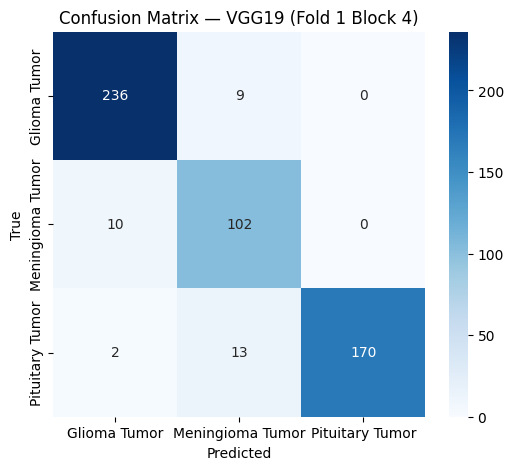

Fold: 1 block 3


Epoch 1/50 | loss: 0.0303 - accuracy: 0.9635 | val_loss: 0.0868 - val_accuracy: 0.9059
val_accuracy improved from 0.0000 to 0.9059, saving weights to /kaggle/working/VGG19_block_3_fold_1.pth


Epoch 2/50 | loss: 0.0255 - accuracy: 0.9659 | val_loss: 0.0626 - val_accuracy: 0.9373
val_accuracy improved from 0.9059 to 0.9373, saving weights to /kaggle/working/VGG19_block_3_fold_1.pth


Epoch 3/50 | loss: 0.0242 - accuracy: 0.9679 | val_loss: 0.0646 - val_accuracy: 0.9354
val_accuracy did not improve from 0.9373


Epoch 4/50 | loss: 0.0187 - accuracy: 0.9750 | val_loss: 0.0647 - val_accuracy: 0.9465
val_accuracy improved from 0.9373 to 0.9465, saving weights to /kaggle/working/VGG19_block_3_fold_1.pth


...

Epoch 12/50 | loss: 0.0099 - accuracy: 0.9897 | val_loss: 0.0964 - val_accuracy: 0.9207
val_accuracy did not improve from 0.9576


Epoch 13/50 | loss: 0.0069 - accuracy: 0.9921 | val_loss: 0.0664 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9576


Epoch 14/50 | loss: 0.0071 - accuracy: 0.9909 | val_loss: 0.0679 - val_accuracy: 0.9465
val_accuracy did not improve from 0.9576


Epoch 15/50 | loss: 0.0064 - accuracy: 0.9925 | val_loss: 0.0660 - val_accuracy: 0.9465
val_accuracy did not improve from 0.9576


Epoch 16/50 | loss: 0.0037 - accuracy: 0.9937 | val_loss: 0.0759 - val_accuracy: 0.9410
val_accuracy did not improve from 0.9576
early stopping, restoring model weights from the end of the best epoch
   Model    Loss  Accuracy
0  VGG19  0.0519  0.957565
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.98      0.96       245
Meningioma Tumor       0.93      0.89      0.91       112
 Pituitary Tumor       0.99      0.96      0.98       185

        accuracy                           0.96       542
       macro avg       0.96      0.95      0.95       542
    weighted avg       0.96      0.96      0.96       542



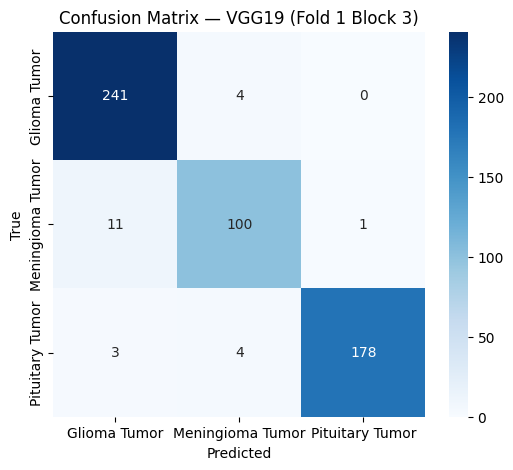

Fold: 1 block 2


Epoch 1/50 | loss: 0.0127 - accuracy: 0.9826 | val_loss: 0.0527 - val_accuracy: 0.9465
val_accuracy improved from 0.0000 to 0.9465, saving weights to /kaggle/working/VGG19_block_2_fold_1.pth


Epoch 2/50 | loss: 0.0149 - accuracy: 0.9818 | val_loss: 0.0784 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9465


Epoch 3/50 | loss: 0.0093 - accuracy: 0.9901 | val_loss: 0.0593 - val_accuracy: 0.9465
val_accuracy did not improve from 0.9465


Epoch 4/50 | loss: 0.0075 - accuracy: 0.9929 | val_loss: 0.0647 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9465


...

Epoch 11/50 | loss: 0.0024 - accuracy: 0.9976 | val_loss: 0.0620 - val_accuracy: 0.9502
val_accuracy did not improve from 0.9613


Epoch 12/50 | loss: 0.0033 - accuracy: 0.9968 | val_loss: 0.0520 - val_accuracy: 0.9576
val_accuracy did not improve from 0.9613


Epoch 13/50 | loss: 0.0032 - accuracy: 0.9952 | val_loss: 0.0605 - val_accuracy: 0.9483
val_accuracy did not improve from 0.9613


Epoch 14/50 | loss: 0.0041 - accuracy: 0.9972 | val_loss: 0.0563 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9613


Epoch 15/50 | loss: 0.0026 - accuracy: 0.9980 | val_loss: 0.0556 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9613
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.047347  0.961255
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.96      0.97       245
Meningioma Tumor       0.87      0.96      0.92       112
 Pituitary Tumor       1.00      0.96      0.98       185

        accuracy                           0.96       542
       macro avg       0.95      0.96      0.95       542
    weighted avg       0.96      0.96      0.96       542



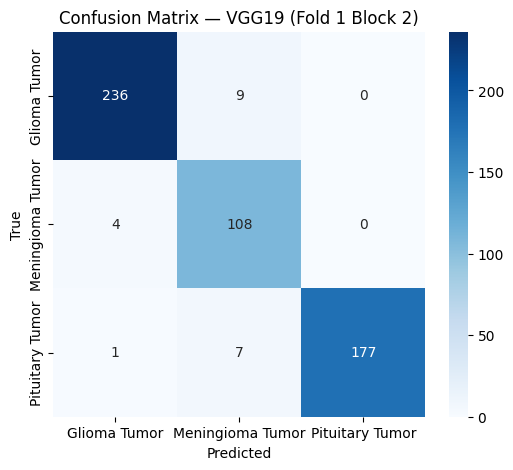

Fold: 1 block 1


Epoch 1/50 | loss: 0.0148 - accuracy: 0.9837 | val_loss: 0.0375 - val_accuracy: 0.9613
val_accuracy improved from 0.0000 to 0.9613, saving weights to /kaggle/working/VGG19_block_1_fold_1.pth


Epoch 2/50 | loss: 0.0039 - accuracy: 0.9952 | val_loss: 0.0504 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9613


Epoch 3/50 | loss: 0.0054 - accuracy: 0.9929 | val_loss: 0.1248 - val_accuracy: 0.9151
val_accuracy did not improve from 0.9613


Epoch 4/50 | loss: 0.0094 - accuracy: 0.9917 | val_loss: 0.0807 - val_accuracy: 0.9262
val_accuracy did not improve from 0.9613


Epoch 5/50 | loss: 0.0056 - accuracy: 0.9937 | val_loss: 0.0610 - val_accuracy: 0.9483
val_accuracy did not improve from 0.9613


Epoch 6/50 | loss: 0.0030 - accuracy: 0.9964 | val_loss: 0.0537 - val_accuracy: 0.9576
val_accuracy did not improve from 0.9613


Epoch 7/50 | loss: 0.0024 - accuracy: 0.9968 | val_loss: 0.0484 - val_accuracy: 0.9613
val_accuracy did not improve from 0.9613
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG19  0.03753  0.961255
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.97      0.97       245
Meningioma Tumor       0.89      0.94      0.91       112
 Pituitary Tumor       1.00      0.96      0.98       185

        accuracy                           0.96       542
       macro avg       0.95      0.96      0.95       542
    weighted avg       0.96      0.96      0.96       542



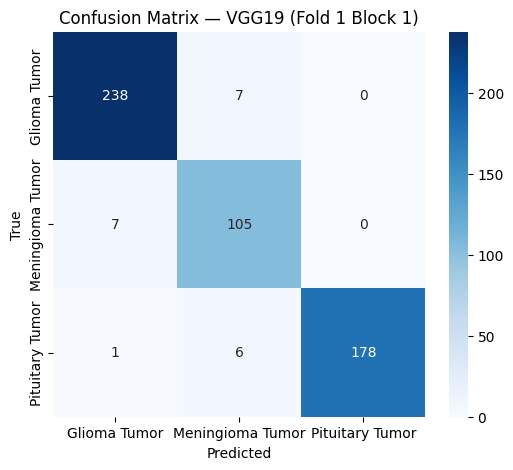

Fold: 2 block 6


Epoch 1/50 | loss: 0.4992 - accuracy: 0.3639 | val_loss: 0.4613 - val_accuracy: 0.4875
val_accuracy improved from 0.0000 to 0.4875, saving weights to /kaggle/working/VGG19_block_6_fold_2.pth


Epoch 2/50 | loss: 0.4461 - accuracy: 0.5061 | val_loss: 0.4272 - val_accuracy: 0.5596
val_accuracy improved from 0.4875 to 0.5596, saving weights to /kaggle/working/VGG19_block_6_fold_2.pth


Epoch 3/50 | loss: 0.4166 - accuracy: 0.5807 | val_loss: 0.3961 - val_accuracy: 0.6303
val_accuracy improved from 0.5596 to 0.6303, saving weights to /kaggle/working/VGG19_block_6_fold_2.pth


Epoch 4/50 | loss: 0.3858 - accuracy: 0.6310 | val_loss: 0.3737 - val_accuracy: 0.6568
val_accuracy improved from 0.6303 to 0.6568, saving weights to /kaggle/working/VGG19_block_6_fold_2.pth


...

Epoch 39/50 | loss: 0.1875 - accuracy: 0.8159 | val_loss: 0.1851 - val_accuracy: 0.7923
val_accuracy did not improve from 0.7968


Epoch 40/50 | loss: 0.1824 - accuracy: 0.8151 | val_loss: 0.1838 - val_accuracy: 0.7953
val_accuracy did not improve from 0.7968


Epoch 41/50 | loss: 0.1782 - accuracy: 0.8218 | val_loss: 0.1819 - val_accuracy: 0.7968
val_accuracy did not improve from 0.7968


Epoch 42/50 | loss: 0.1810 - accuracy: 0.8092 | val_loss: 0.1807 - val_accuracy: 0.7953
val_accuracy did not improve from 0.7968


Epoch 43/50 | loss: 0.1839 - accuracy: 0.8130 | val_loss: 0.1793 - val_accuracy: 0.7968
val_accuracy did not improve from 0.7968
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.184643   0.79676
                  precision    recall  f1-score   support

    Glioma Tumor       0.76      0.91      0.83       338
Meningioma Tumor       0.70      0.51      0.60       167
 Pituitary Tumor       0.95      0.84      0.89       174

        accuracy                           0.80       679
       macro avg       0.81      0.76      0.77       679
    weighted avg       0.80      0.80      0.79       679



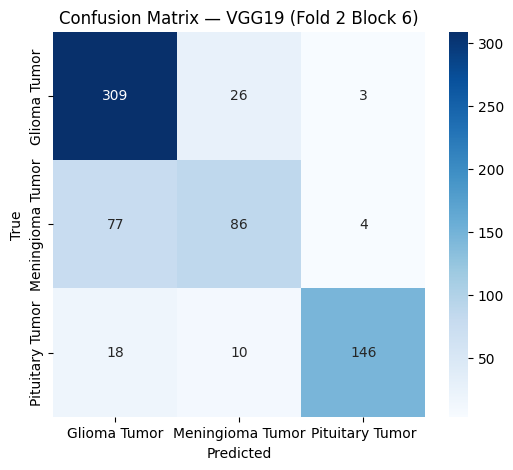

Fold: 2 block 5


Epoch 1/50 | loss: 0.1649 - accuracy: 0.8256 | val_loss: 0.1383 - val_accuracy: 0.8247
val_accuracy improved from 0.0000 to 0.8247, saving weights to /kaggle/working/VGG19_block_5_fold_2.pth


Epoch 2/50 | loss: 0.1247 - accuracy: 0.8650 | val_loss: 0.1327 - val_accuracy: 0.8292
val_accuracy improved from 0.8247 to 0.8292, saving weights to /kaggle/working/VGG19_block_5_fold_2.pth


Epoch 3/50 | loss: 0.1112 - accuracy: 0.8763 | val_loss: 0.1314 - val_accuracy: 0.8321
val_accuracy improved from 0.8292 to 0.8321, saving weights to /kaggle/working/VGG19_block_5_fold_2.pth


Epoch 4/50 | loss: 0.1016 - accuracy: 0.8855 | val_loss: 0.1314 - val_accuracy: 0.8454
val_accuracy improved from 0.8321 to 0.8454, saving weights to /kaggle/working/VGG19_block_5_fold_2.pth


...

Epoch 15/50 | loss: 0.0499 - accuracy: 0.9405 | val_loss: 0.1085 - val_accuracy: 0.8881
val_accuracy did not improve from 0.8954


Epoch 16/50 | loss: 0.0434 - accuracy: 0.9463 | val_loss: 0.1136 - val_accuracy: 0.8822
val_accuracy did not improve from 0.8954


Epoch 17/50 | loss: 0.0439 - accuracy: 0.9442 | val_loss: 0.0931 - val_accuracy: 0.8954
val_accuracy did not improve from 0.8954


Epoch 18/50 | loss: 0.0423 - accuracy: 0.9463 | val_loss: 0.0942 - val_accuracy: 0.8910
val_accuracy did not improve from 0.8954


Epoch 19/50 | loss: 0.0401 - accuracy: 0.9484 | val_loss: 0.1005 - val_accuracy: 0.8954
val_accuracy did not improve from 0.8954
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.103148  0.895434
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.95      0.92       338
Meningioma Tumor       0.85      0.79      0.82       167
 Pituitary Tumor       0.96      0.90      0.93       174

        accuracy                           0.90       679
       macro avg       0.90      0.88      0.89       679
    weighted avg       0.90      0.90      0.89       679



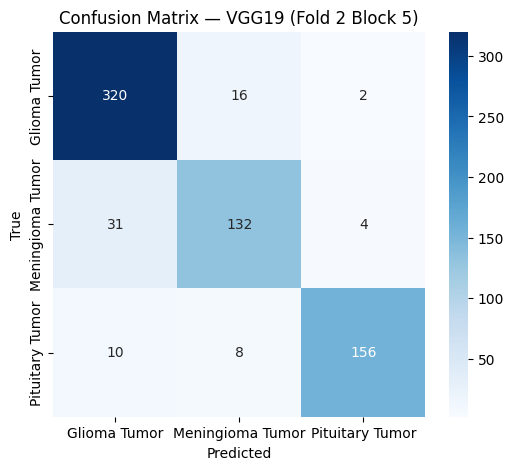

Fold: 2 block 4


Epoch 1/50 | loss: 0.0534 - accuracy: 0.9283 | val_loss: 0.1309 - val_accuracy: 0.8748
val_accuracy improved from 0.0000 to 0.8748, saving weights to /kaggle/working/VGG19_block_4_fold_2.pth


Epoch 2/50 | loss: 0.0432 - accuracy: 0.9426 | val_loss: 0.0884 - val_accuracy: 0.9043
val_accuracy improved from 0.8748 to 0.9043, saving weights to /kaggle/working/VGG19_block_4_fold_2.pth


Epoch 3/50 | loss: 0.0366 - accuracy: 0.9530 | val_loss: 0.1025 - val_accuracy: 0.9087
val_accuracy improved from 0.9043 to 0.9087, saving weights to /kaggle/working/VGG19_block_4_fold_2.pth


Epoch 4/50 | loss: 0.0365 - accuracy: 0.9543 | val_loss: 0.1009 - val_accuracy: 0.8910
val_accuracy did not improve from 0.9087


...

Epoch 7/50 | loss: 0.0269 - accuracy: 0.9698 | val_loss: 0.0850 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9161


Epoch 8/50 | loss: 0.0260 - accuracy: 0.9644 | val_loss: 0.0841 - val_accuracy: 0.9116
val_accuracy did not improve from 0.9161


Epoch 9/50 | loss: 0.0210 - accuracy: 0.9761 | val_loss: 0.1283 - val_accuracy: 0.9087
val_accuracy did not improve from 0.9161


Epoch 10/50 | loss: 0.0246 - accuracy: 0.9698 | val_loss: 0.1611 - val_accuracy: 0.9057
val_accuracy did not improve from 0.9161


Epoch 11/50 | loss: 0.0168 - accuracy: 0.9790 | val_loss: 0.1066 - val_accuracy: 0.9161
val_accuracy did not improve from 0.9161
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.088328  0.916053
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.96      0.93       338
Meningioma Tumor       0.89      0.82      0.85       167
 Pituitary Tumor       0.95      0.93      0.94       174

        accuracy                           0.92       679
       macro avg       0.92      0.90      0.91       679
    weighted avg       0.92      0.92      0.92       679



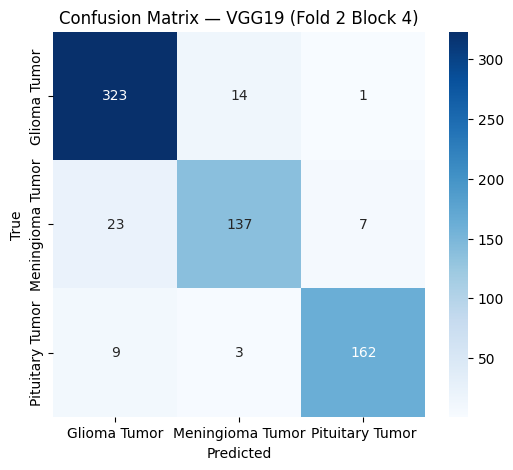

Fold: 2 block 3


Epoch 1/50 | loss: 0.0329 - accuracy: 0.9581 | val_loss: 0.0962 - val_accuracy: 0.9102
val_accuracy improved from 0.0000 to 0.9102, saving weights to /kaggle/working/VGG19_block_3_fold_2.pth


Epoch 2/50 | loss: 0.0279 - accuracy: 0.9694 | val_loss: 0.0966 - val_accuracy: 0.9146
val_accuracy improved from 0.9102 to 0.9146, saving weights to /kaggle/working/VGG19_block_3_fold_2.pth


Epoch 3/50 | loss: 0.0279 - accuracy: 0.9702 | val_loss: 0.1590 - val_accuracy: 0.8984
val_accuracy did not improve from 0.9146


Epoch 4/50 | loss: 0.0193 - accuracy: 0.9719 | val_loss: 0.0863 - val_accuracy: 0.9175
val_accuracy improved from 0.9146 to 0.9175, saving weights to /kaggle/working/VGG19_block_3_fold_2.pth


...

Epoch 6/50 | loss: 0.0134 - accuracy: 0.9828 | val_loss: 0.2408 - val_accuracy: 0.8689
val_accuracy did not improve from 0.9175


Epoch 7/50 | loss: 0.0167 - accuracy: 0.9748 | val_loss: 0.1074 - val_accuracy: 0.9116
val_accuracy did not improve from 0.9175


Epoch 8/50 | loss: 0.0127 - accuracy: 0.9816 | val_loss: 0.1004 - val_accuracy: 0.9087
val_accuracy did not improve from 0.9175


Epoch 9/50 | loss: 0.0103 - accuracy: 0.9862 | val_loss: 0.1048 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9175


Epoch 10/50 | loss: 0.0084 - accuracy: 0.9904 | val_loss: 0.0979 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9175
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.086343  0.917526
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.95      0.94       338
Meningioma Tumor       0.87      0.83      0.85       167
 Pituitary Tumor       0.94      0.94      0.94       174

        accuracy                           0.92       679
       macro avg       0.91      0.91      0.91       679
    weighted avg       0.92      0.92      0.92       679



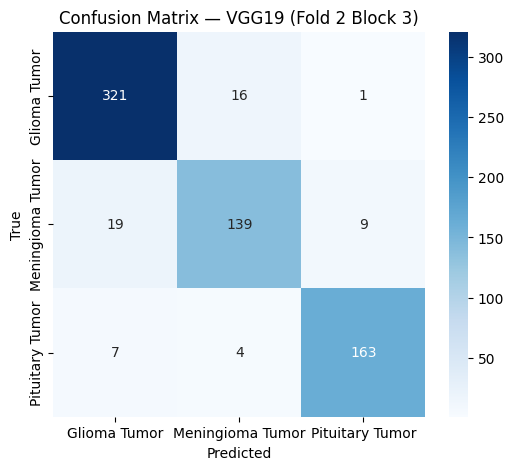

Fold: 2 block 2


Epoch 1/50 | loss: 0.0230 - accuracy: 0.9715 | val_loss: 0.1255 - val_accuracy: 0.9102
val_accuracy improved from 0.0000 to 0.9102, saving weights to /kaggle/working/VGG19_block_2_fold_2.pth


Epoch 2/50 | loss: 0.0192 - accuracy: 0.9774 | val_loss: 0.0871 - val_accuracy: 0.9146
val_accuracy improved from 0.9102 to 0.9146, saving weights to /kaggle/working/VGG19_block_2_fold_2.pth


Epoch 3/50 | loss: 0.0163 - accuracy: 0.9811 | val_loss: 0.0761 - val_accuracy: 0.9161
val_accuracy improved from 0.9146 to 0.9161, saving weights to /kaggle/working/VGG19_block_2_fold_2.pth


Epoch 4/50 | loss: 0.0135 - accuracy: 0.9845 | val_loss: 0.0984 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9161


...

Epoch 9/50 | loss: 0.0054 - accuracy: 0.9937 | val_loss: 0.1214 - val_accuracy: 0.9087
val_accuracy did not improve from 0.9190


Epoch 10/50 | loss: 0.0040 - accuracy: 0.9966 | val_loss: 0.1271 - val_accuracy: 0.9087
val_accuracy did not improve from 0.9190


Epoch 11/50 | loss: 0.0053 - accuracy: 0.9933 | val_loss: 0.1392 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9190


Epoch 12/50 | loss: 0.0054 - accuracy: 0.9929 | val_loss: 0.1196 - val_accuracy: 0.9116
val_accuracy did not improve from 0.9190


Epoch 13/50 | loss: 0.0067 - accuracy: 0.9925 | val_loss: 0.1331 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9190
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.086806  0.918999
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.91      0.93       338
Meningioma Tumor       0.81      0.92      0.87       167
 Pituitary Tumor       0.98      0.93      0.96       174

        accuracy                           0.92       679
       macro avg       0.91      0.92      0.92       679
    weighted avg       0.92      0.92      0.92       679



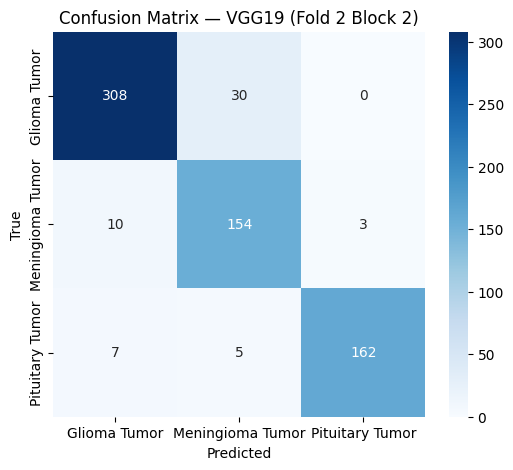

Fold: 2 block 1


Epoch 1/50 | loss: 0.0104 - accuracy: 0.9883 | val_loss: 0.1328 - val_accuracy: 0.9131
val_accuracy improved from 0.0000 to 0.9131, saving weights to /kaggle/working/VGG19_block_1_fold_2.pth


Epoch 2/50 | loss: 0.0116 - accuracy: 0.9849 | val_loss: 0.1461 - val_accuracy: 0.9057
val_accuracy did not improve from 0.9131


Epoch 3/50 | loss: 0.0090 - accuracy: 0.9883 | val_loss: 0.0855 - val_accuracy: 0.9219
val_accuracy improved from 0.9131 to 0.9219, saving weights to /kaggle/working/VGG19_block_1_fold_2.pth


Epoch 4/50 | loss: 0.0084 - accuracy: 0.9904 | val_loss: 0.1128 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9219


...

Epoch 9/50 | loss: 0.0044 - accuracy: 0.9954 | val_loss: 0.1053 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9293


Epoch 10/50 | loss: 0.0040 - accuracy: 0.9958 | val_loss: 0.1083 - val_accuracy: 0.9175
val_accuracy did not improve from 0.9293


Epoch 11/50 | loss: 0.0022 - accuracy: 0.9987 | val_loss: 0.1033 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9293


Epoch 12/50 | loss: 0.0018 - accuracy: 0.9983 | val_loss: 0.0928 - val_accuracy: 0.9249
val_accuracy did not improve from 0.9293


Epoch 13/50 | loss: 0.0013 - accuracy: 0.9987 | val_loss: 0.1122 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9293
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.177635  0.929308
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.97      0.94       338
Meningioma Tumor       0.92      0.88      0.90       167
 Pituitary Tumor       0.99      0.89      0.94       174

        accuracy                           0.93       679
       macro avg       0.94      0.91      0.93       679
    weighted avg       0.93      0.93      0.93       679



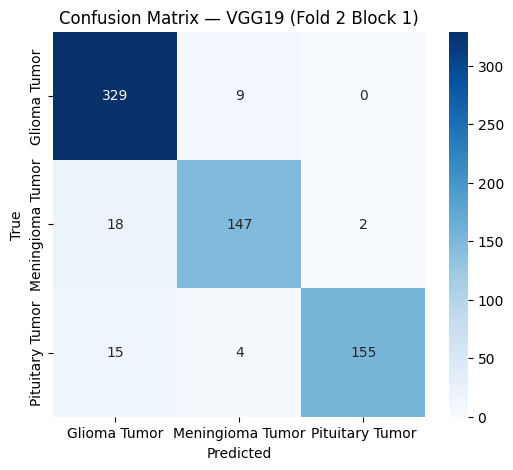

Fold: 3 block 6


Epoch 1/50 | loss: 0.4620 - accuracy: 0.4522 | val_loss: 0.4411 - val_accuracy: 0.5245
val_accuracy improved from 0.0000 to 0.5245, saving weights to /kaggle/working/VGG19_block_6_fold_3.pth


Epoch 2/50 | loss: 0.4269 - accuracy: 0.5185 | val_loss: 0.4031 - val_accuracy: 0.6311
val_accuracy improved from 0.5245 to 0.6311, saving weights to /kaggle/working/VGG19_block_6_fold_3.pth


Epoch 3/50 | loss: 0.3924 - accuracy: 0.5859 | val_loss: 0.3748 - val_accuracy: 0.6766
val_accuracy improved from 0.6311 to 0.6766, saving weights to /kaggle/working/VGG19_block_6_fold_3.pth


Epoch 4/50 | loss: 0.3689 - accuracy: 0.6340 | val_loss: 0.3508 - val_accuracy: 0.6836
val_accuracy improved from 0.6766 to 0.6836, saving weights to /kaggle/working/VGG19_block_6_fold_3.pth


...

Epoch 21/50 | loss: 0.2136 - accuracy: 0.8098 | val_loss: 0.2085 - val_accuracy: 0.7937
val_accuracy did not improve from 0.8077


Epoch 22/50 | loss: 0.2161 - accuracy: 0.7957 | val_loss: 0.2046 - val_accuracy: 0.7972
val_accuracy did not improve from 0.8077


Epoch 23/50 | loss: 0.2107 - accuracy: 0.7970 | val_loss: 0.2002 - val_accuracy: 0.7990
val_accuracy did not improve from 0.8077


Epoch 24/50 | loss: 0.2084 - accuracy: 0.8062 | val_loss: 0.2014 - val_accuracy: 0.7937
val_accuracy did not improve from 0.8077


Epoch 25/50 | loss: 0.2086 - accuracy: 0.7970 | val_loss: 0.1993 - val_accuracy: 0.7937
val_accuracy did not improve from 0.8077
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.209491  0.807692
                  precision    recall  f1-score   support

    Glioma Tumor       0.71      0.92      0.80       231
Meningioma Tumor       0.77      0.47      0.58       139
 Pituitary Tumor       0.97      0.92      0.94       202

        accuracy                           0.81       572
       macro avg       0.82      0.77      0.78       572
    weighted avg       0.82      0.81      0.80       572



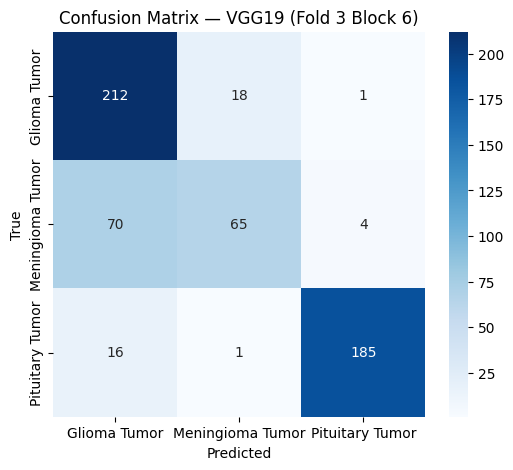

Fold: 3 block 5


Epoch 1/50 | loss: 0.1807 - accuracy: 0.8214 | val_loss: 0.1359 - val_accuracy: 0.8444
val_accuracy improved from 0.0000 to 0.8444, saving weights to /kaggle/working/VGG19_block_5_fold_3.pth


Epoch 2/50 | loss: 0.1299 - accuracy: 0.8600 | val_loss: 0.1217 - val_accuracy: 0.8584
val_accuracy improved from 0.8444 to 0.8584, saving weights to /kaggle/working/VGG19_block_5_fold_3.pth


Epoch 3/50 | loss: 0.1176 - accuracy: 0.8692 | val_loss: 0.1061 - val_accuracy: 0.8741
val_accuracy improved from 0.8584 to 0.8741, saving weights to /kaggle/working/VGG19_block_5_fold_3.pth


Epoch 4/50 | loss: 0.1011 - accuracy: 0.8836 | val_loss: 0.1080 - val_accuracy: 0.8654
val_accuracy did not improve from 0.8741


Epoch 5/50 | loss: 0.0944 - accuracy: 0.8949 | val_loss: 0.1132 - val_accuracy: 0.8601
val_accuracy did not improve from 0.8741


Epoch 6/50 | loss: 0.0847 - accuracy: 0.9065 | val_loss: 0.1003 - val_accuracy: 0.8741
val_accuracy did not improve from 0.8741


Epoch 7/50 | loss: 0.0835 - accuracy: 0.9013 | val_loss: 0.0963 - val_accuracy: 0.8724
val_accuracy did not improve from 0.8741


Epoch 8/50 | loss: 0.0722 - accuracy: 0.9161 | val_loss: 0.1129 - val_accuracy: 0.8549
val_accuracy did not improve from 0.8741


Epoch 9/50 | loss: 0.0749 - accuracy: 0.9137 | val_loss: 0.0974 - val_accuracy: 0.8741
val_accuracy did not improve from 0.8741
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.106102  0.874126
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.87      0.87       231
Meningioma Tumor       0.75      0.75      0.75       139
 Pituitary Tumor       0.97      0.97      0.97       202

        accuracy                           0.87       572
       macro avg       0.86      0.86      0.86       572
    weighted avg       0.87      0.87      0.87       572



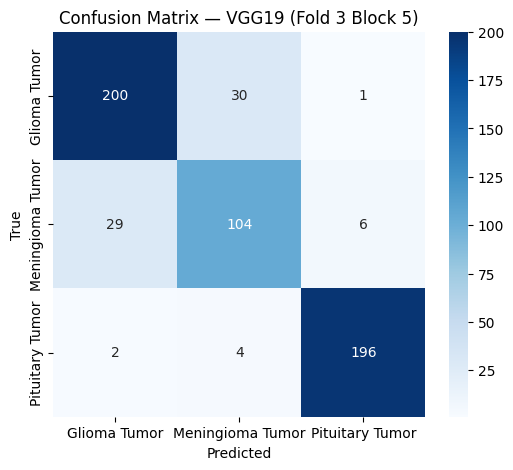

Fold: 3 block 4


Epoch 1/50 | loss: 0.1017 - accuracy: 0.8824 | val_loss: 0.1220 - val_accuracy: 0.8427
val_accuracy improved from 0.0000 to 0.8427, saving weights to /kaggle/working/VGG19_block_4_fold_3.pth


Epoch 2/50 | loss: 0.0822 - accuracy: 0.9045 | val_loss: 0.0898 - val_accuracy: 0.8654
val_accuracy improved from 0.8427 to 0.8654, saving weights to /kaggle/working/VGG19_block_4_fold_3.pth


Epoch 3/50 | loss: 0.0732 - accuracy: 0.9173 | val_loss: 0.1024 - val_accuracy: 0.8514
val_accuracy did not improve from 0.8654


Epoch 4/50 | loss: 0.0661 - accuracy: 0.9193 | val_loss: 0.0843 - val_accuracy: 0.8811
val_accuracy improved from 0.8654 to 0.8811, saving weights to /kaggle/working/VGG19_block_4_fold_3.pth


...

Epoch 16/50 | loss: 0.0146 - accuracy: 0.9799 | val_loss: 0.0698 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9266


Epoch 17/50 | loss: 0.0143 - accuracy: 0.9819 | val_loss: 0.0696 - val_accuracy: 0.9266
val_accuracy did not improve from 0.9266


Epoch 18/50 | loss: 0.0129 - accuracy: 0.9843 | val_loss: 0.0699 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9266


Epoch 19/50 | loss: 0.0119 - accuracy: 0.9852 | val_loss: 0.0701 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9266


Epoch 20/50 | loss: 0.0134 - accuracy: 0.9839 | val_loss: 0.0704 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9266
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.068342  0.926573
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.92      0.92       231
Meningioma Tumor       0.83      0.87      0.85       139
 Pituitary Tumor       0.99      0.98      0.98       202

        accuracy                           0.93       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



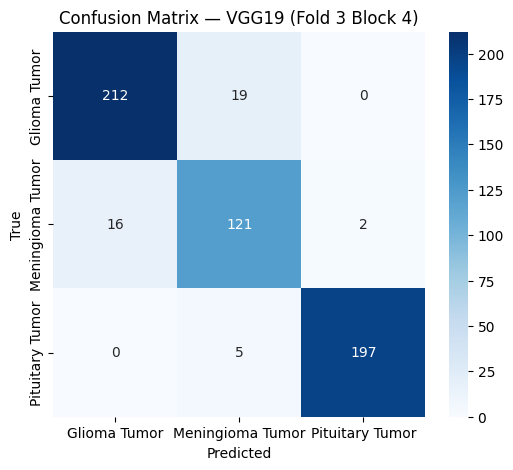

Fold: 3 block 3


Epoch 1/50 | loss: 0.0235 - accuracy: 0.9727 | val_loss: 0.0683 - val_accuracy: 0.9231
val_accuracy improved from 0.0000 to 0.9231, saving weights to /kaggle/working/VGG19_block_3_fold_3.pth


Epoch 2/50 | loss: 0.0183 - accuracy: 0.9747 | val_loss: 0.0662 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9231


Epoch 3/50 | loss: 0.0202 - accuracy: 0.9779 | val_loss: 0.0617 - val_accuracy: 0.9301
val_accuracy improved from 0.9231 to 0.9301, saving weights to /kaggle/working/VGG19_block_3_fold_3.pth


Epoch 4/50 | loss: 0.0162 - accuracy: 0.9799 | val_loss: 0.0737 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9301


...

Epoch 8/50 | loss: 0.0100 - accuracy: 0.9896 | val_loss: 0.0757 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9406


Epoch 9/50 | loss: 0.0105 - accuracy: 0.9900 | val_loss: 0.0682 - val_accuracy: 0.9318
val_accuracy did not improve from 0.9406


Epoch 10/50 | loss: 0.0091 - accuracy: 0.9896 | val_loss: 0.0652 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9406


Epoch 11/50 | loss: 0.0057 - accuracy: 0.9940 | val_loss: 0.0673 - val_accuracy: 0.9353
val_accuracy did not improve from 0.9406


Epoch 12/50 | loss: 0.0057 - accuracy: 0.9952 | val_loss: 0.0688 - val_accuracy: 0.9353
val_accuracy did not improve from 0.9406
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.061228  0.940559
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.92      0.93       231
Meningioma Tumor       0.87      0.88      0.88       139
 Pituitary Tumor       0.98      1.00      0.99       202

        accuracy                           0.94       572
       macro avg       0.93      0.94      0.93       572
    weighted avg       0.94      0.94      0.94       572



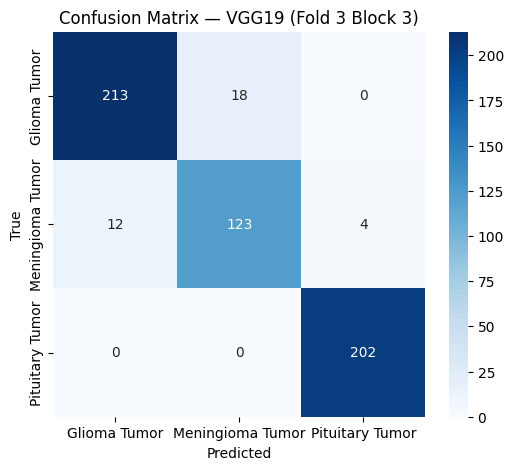

Fold: 3 block 2


Epoch 1/50 | loss: 0.0177 - accuracy: 0.9799 | val_loss: 0.0581 - val_accuracy: 0.9283
val_accuracy improved from 0.0000 to 0.9283, saving weights to /kaggle/working/VGG19_block_2_fold_3.pth


Epoch 2/50 | loss: 0.0088 - accuracy: 0.9904 | val_loss: 0.0867 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9283


Epoch 3/50 | loss: 0.0102 - accuracy: 0.9835 | val_loss: 0.1147 - val_accuracy: 0.8829
val_accuracy did not improve from 0.9283


Epoch 4/50 | loss: 0.0141 - accuracy: 0.9843 | val_loss: 0.0910 - val_accuracy: 0.9003
val_accuracy did not improve from 0.9283


...

Epoch 16/50 | loss: 0.0030 - accuracy: 0.9968 | val_loss: 0.0798 - val_accuracy: 0.9371
val_accuracy did not improve from 0.9388


Epoch 17/50 | loss: 0.0031 - accuracy: 0.9980 | val_loss: 0.0791 - val_accuracy: 0.9388
val_accuracy did not improve from 0.9388


Epoch 18/50 | loss: 0.0023 - accuracy: 0.9980 | val_loss: 0.0793 - val_accuracy: 0.9371
val_accuracy did not improve from 0.9388


Epoch 19/50 | loss: 0.0026 - accuracy: 0.9976 | val_loss: 0.0799 - val_accuracy: 0.9353
val_accuracy did not improve from 0.9388


Epoch 20/50 | loss: 0.0025 - accuracy: 0.9980 | val_loss: 0.0799 - val_accuracy: 0.9388
val_accuracy did not improve from 0.9388
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.078022  0.938811
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.92      0.94       231
Meningioma Tumor       0.86      0.90      0.88       139
 Pituitary Tumor       0.99      0.99      0.99       202

        accuracy                           0.94       572
       macro avg       0.93      0.94      0.93       572
    weighted avg       0.94      0.94      0.94       572



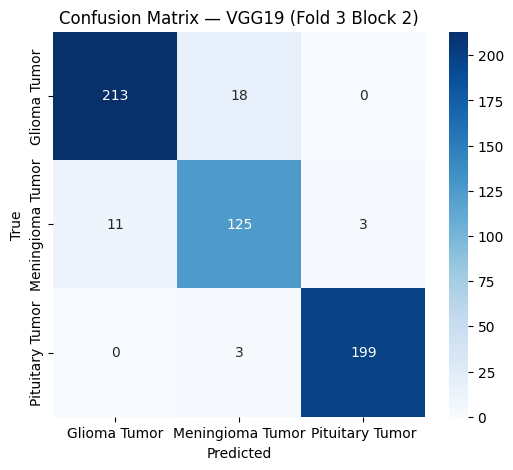

Fold: 3 block 1


Epoch 1/50 | loss: 0.0120 - accuracy: 0.9892 | val_loss: 0.0726 - val_accuracy: 0.9301
val_accuracy improved from 0.0000 to 0.9301, saving weights to /kaggle/working/VGG19_block_1_fold_3.pth


Epoch 2/50 | loss: 0.0062 - accuracy: 0.9932 | val_loss: 0.0763 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9301


Epoch 3/50 | loss: 0.0081 - accuracy: 0.9924 | val_loss: 0.0846 - val_accuracy: 0.9336
val_accuracy improved from 0.9301 to 0.9336, saving weights to /kaggle/working/VGG19_block_1_fold_3.pth


Epoch 4/50 | loss: 0.0081 - accuracy: 0.9912 | val_loss: 0.1008 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9336


...

Epoch 8/50 | loss: 0.0029 - accuracy: 0.9964 | val_loss: 0.1114 - val_accuracy: 0.9353
val_accuracy did not improve from 0.9388


Epoch 9/50 | loss: 0.0074 - accuracy: 0.9896 | val_loss: 0.1026 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9388


Epoch 10/50 | loss: 0.0032 - accuracy: 0.9972 | val_loss: 0.1112 - val_accuracy: 0.9213
val_accuracy did not improve from 0.9388


Epoch 11/50 | loss: 0.0025 - accuracy: 0.9972 | val_loss: 0.0997 - val_accuracy: 0.9318
val_accuracy did not improve from 0.9388


Epoch 12/50 | loss: 0.0014 - accuracy: 0.9980 | val_loss: 0.1014 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9388
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.081949  0.938811
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.93      0.94       231
Meningioma Tumor       0.85      0.91      0.88       139
 Pituitary Tumor       0.99      0.98      0.98       202

        accuracy                           0.94       572
       macro avg       0.93      0.94      0.93       572
    weighted avg       0.94      0.94      0.94       572



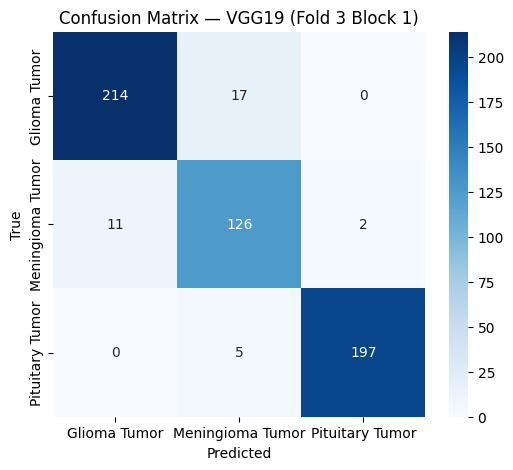

Fold: 4 block 6


Epoch 1/50 | loss: 0.4958 - accuracy: 0.3768 | val_loss: 0.4674 - val_accuracy: 0.4061
val_accuracy improved from 0.0000 to 0.4061, saving weights to /kaggle/working/VGG19_block_6_fold_4.pth


Epoch 2/50 | loss: 0.4528 - accuracy: 0.4762 | val_loss: 0.4219 - val_accuracy: 0.5414
val_accuracy improved from 0.4061 to 0.5414, saving weights to /kaggle/working/VGG19_block_6_fold_4.pth


Epoch 3/50 | loss: 0.4190 - accuracy: 0.5517 | val_loss: 0.3865 - val_accuracy: 0.6672
val_accuracy improved from 0.5414 to 0.6672, saving weights to /kaggle/working/VGG19_block_6_fold_4.pth


Epoch 4/50 | loss: 0.3930 - accuracy: 0.5920 | val_loss: 0.3562 - val_accuracy: 0.7357
val_accuracy improved from 0.6672 to 0.7357, saving weights to /kaggle/working/VGG19_block_6_fold_4.pth


...

Epoch 27/50 | loss: 0.2130 - accuracy: 0.7853 | val_loss: 0.1681 - val_accuracy: 0.8631
val_accuracy did not improve from 0.8678


Epoch 28/50 | loss: 0.2110 - accuracy: 0.7820 | val_loss: 0.1662 - val_accuracy: 0.8599
val_accuracy did not improve from 0.8678


Epoch 29/50 | loss: 0.2096 - accuracy: 0.7939 | val_loss: 0.1634 - val_accuracy: 0.8631
val_accuracy did not improve from 0.8678


Epoch 30/50 | loss: 0.2039 - accuracy: 0.7956 | val_loss: 0.1653 - val_accuracy: 0.8503
val_accuracy did not improve from 0.8678


Epoch 31/50 | loss: 0.2103 - accuracy: 0.7833 | val_loss: 0.1602 - val_accuracy: 0.8615
val_accuracy did not improve from 0.8678
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.171318  0.867834
                  precision    recall  f1-score   support

    Glioma Tumor       0.84      0.96      0.90       325
Meningioma Tumor       0.84      0.57      0.68       124
 Pituitary Tumor       0.94      0.91      0.92       179

        accuracy                           0.87       628
       macro avg       0.87      0.81      0.83       628
    weighted avg       0.87      0.87      0.86       628



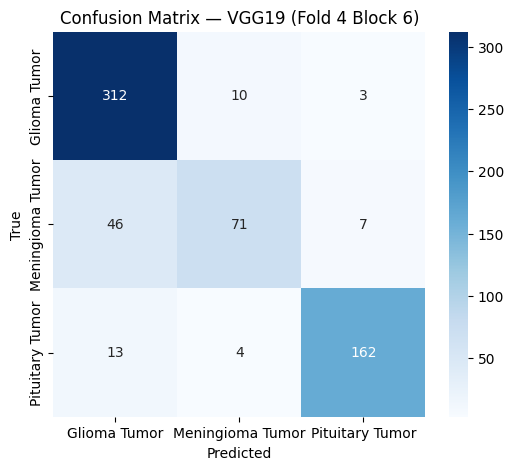

Fold: 4 block 5


Epoch 1/50 | loss: 0.1807 - accuracy: 0.8079 | val_loss: 0.1129 - val_accuracy: 0.8933
val_accuracy improved from 0.0000 to 0.8933, saving weights to /kaggle/working/VGG19_block_5_fold_4.pth


Epoch 2/50 | loss: 0.1452 - accuracy: 0.8378 | val_loss: 0.0961 - val_accuracy: 0.8933
val_accuracy did not improve from 0.8933


Epoch 3/50 | loss: 0.1185 - accuracy: 0.8670 | val_loss: 0.0935 - val_accuracy: 0.8901
val_accuracy did not improve from 0.8933


Epoch 4/50 | loss: 0.1059 - accuracy: 0.8830 | val_loss: 0.0943 - val_accuracy: 0.8949
val_accuracy improved from 0.8933 to 0.8949, saving weights to /kaggle/working/VGG19_block_5_fold_4.pth


...

Epoch 15/50 | loss: 0.0521 - accuracy: 0.9360 | val_loss: 0.0741 - val_accuracy: 0.9172
val_accuracy did not improve from 0.9315


Epoch 16/50 | loss: 0.0485 - accuracy: 0.9388 | val_loss: 0.0708 - val_accuracy: 0.9220
val_accuracy did not improve from 0.9315


Epoch 17/50 | loss: 0.0526 - accuracy: 0.9314 | val_loss: 0.0696 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9315


Epoch 18/50 | loss: 0.0505 - accuracy: 0.9388 | val_loss: 0.0698 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9315


Epoch 19/50 | loss: 0.0442 - accuracy: 0.9487 | val_loss: 0.0785 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9315
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG19  0.06723  0.931529
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.95      0.95       325
Meningioma Tumor       0.83      0.87      0.85       124
 Pituitary Tumor       0.98      0.93      0.96       179

        accuracy                           0.93       628
       macro avg       0.92      0.92      0.92       628
    weighted avg       0.93      0.93      0.93       628



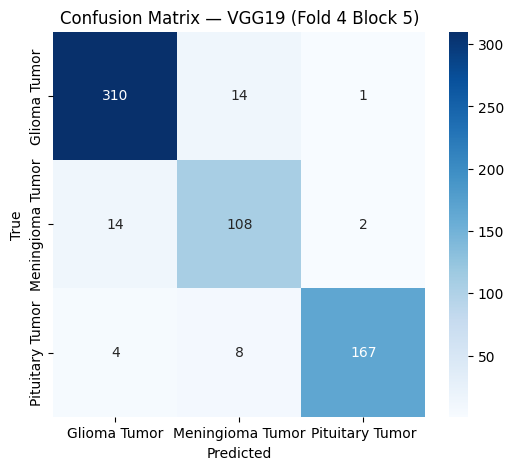

Fold: 4 block 4


Epoch 1/50 | loss: 0.0567 - accuracy: 0.9282 | val_loss: 0.0746 - val_accuracy: 0.9140
val_accuracy improved from 0.0000 to 0.9140, saving weights to /kaggle/working/VGG19_block_4_fold_4.pth


Epoch 2/50 | loss: 0.0474 - accuracy: 0.9384 | val_loss: 0.0801 - val_accuracy: 0.9140
val_accuracy did not improve from 0.9140


Epoch 3/50 | loss: 0.0460 - accuracy: 0.9397 | val_loss: 0.0749 - val_accuracy: 0.9268
val_accuracy improved from 0.9140 to 0.9268, saving weights to /kaggle/working/VGG19_block_4_fold_4.pth


Epoch 4/50 | loss: 0.0353 - accuracy: 0.9557 | val_loss: 0.0665 - val_accuracy: 0.9411
val_accuracy improved from 0.9268 to 0.9411, saving weights to /kaggle/working/VGG19_block_4_fold_4.pth


...

Epoch 6/50 | loss: 0.0307 - accuracy: 0.9626 | val_loss: 0.0791 - val_accuracy: 0.9220
val_accuracy did not improve from 0.9411


Epoch 7/50 | loss: 0.0298 - accuracy: 0.9598 | val_loss: 0.0640 - val_accuracy: 0.9331
val_accuracy did not improve from 0.9411


Epoch 8/50 | loss: 0.0258 - accuracy: 0.9680 | val_loss: 0.0852 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9411


Epoch 9/50 | loss: 0.0239 - accuracy: 0.9692 | val_loss: 0.1005 - val_accuracy: 0.9156
val_accuracy did not improve from 0.9411


Epoch 10/50 | loss: 0.0186 - accuracy: 0.9758 | val_loss: 0.0691 - val_accuracy: 0.9331
val_accuracy did not improve from 0.9411
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.066475  0.941083
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.97      0.96       325
Meningioma Tumor       0.88      0.85      0.87       124
 Pituitary Tumor       0.97      0.94      0.95       179

        accuracy                           0.94       628
       macro avg       0.93      0.92      0.93       628
    weighted avg       0.94      0.94      0.94       628



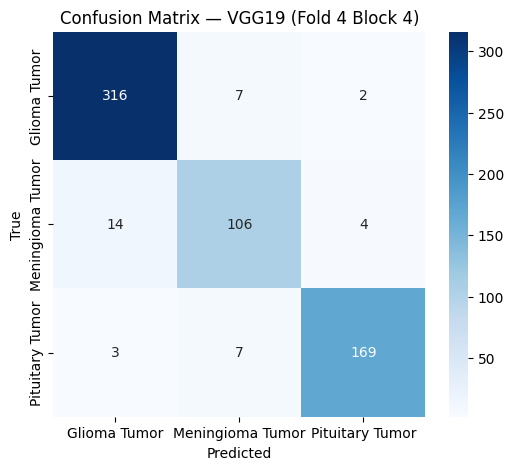

Fold: 4 block 3


Epoch 1/50 | loss: 0.0388 - accuracy: 0.9528 | val_loss: 0.0622 - val_accuracy: 0.9363
val_accuracy improved from 0.0000 to 0.9363, saving weights to /kaggle/working/VGG19_block_3_fold_4.pth


Epoch 2/50 | loss: 0.0305 - accuracy: 0.9680 | val_loss: 0.0599 - val_accuracy: 0.9379
val_accuracy improved from 0.9363 to 0.9379, saving weights to /kaggle/working/VGG19_block_3_fold_4.pth


Epoch 3/50 | loss: 0.0307 - accuracy: 0.9647 | val_loss: 0.0624 - val_accuracy: 0.9347
val_accuracy did not improve from 0.9379


Epoch 4/50 | loss: 0.0263 - accuracy: 0.9684 | val_loss: 0.1009 - val_accuracy: 0.9061
val_accuracy did not improve from 0.9379


...

Epoch 11/50 | loss: 0.0110 - accuracy: 0.9852 | val_loss: 0.0657 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9475


Epoch 12/50 | loss: 0.0113 - accuracy: 0.9865 | val_loss: 0.0660 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9475


Epoch 13/50 | loss: 0.0114 - accuracy: 0.9848 | val_loss: 0.0664 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9475


Epoch 14/50 | loss: 0.0101 - accuracy: 0.9869 | val_loss: 0.0656 - val_accuracy: 0.9443
val_accuracy did not improve from 0.9475


Epoch 15/50 | loss: 0.0120 - accuracy: 0.9860 | val_loss: 0.0657 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9475
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG19  0.06376  0.947452
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.97      0.96       325
Meningioma Tumor       0.86      0.91      0.89       124
 Pituitary Tumor       0.98      0.94      0.96       179

        accuracy                           0.95       628
       macro avg       0.94      0.94      0.94       628
    weighted avg       0.95      0.95      0.95       628



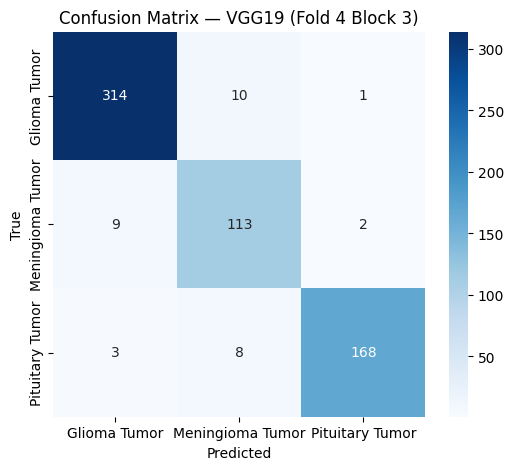

Fold: 4 block 2


Epoch 1/50 | loss: 0.0184 - accuracy: 0.9770 | val_loss: 0.0781 - val_accuracy: 0.9315
val_accuracy improved from 0.0000 to 0.9315, saving weights to /kaggle/working/VGG19_block_2_fold_4.pth


Epoch 2/50 | loss: 0.0234 - accuracy: 0.9729 | val_loss: 0.0656 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9315


Epoch 3/50 | loss: 0.0121 - accuracy: 0.9844 | val_loss: 0.0875 - val_accuracy: 0.9172
val_accuracy did not improve from 0.9315


Epoch 4/50 | loss: 0.0127 - accuracy: 0.9832 | val_loss: 0.0600 - val_accuracy: 0.9459
val_accuracy improved from 0.9315 to 0.9459, saving weights to /kaggle/working/VGG19_block_2_fold_4.pth


...

Epoch 7/50 | loss: 0.0090 - accuracy: 0.9860 | val_loss: 0.0720 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9506


Epoch 8/50 | loss: 0.0083 - accuracy: 0.9877 | val_loss: 0.0750 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9506


Epoch 9/50 | loss: 0.0043 - accuracy: 0.9947 | val_loss: 0.0678 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9506


Epoch 10/50 | loss: 0.0049 - accuracy: 0.9963 | val_loss: 0.0734 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9506


Epoch 11/50 | loss: 0.0040 - accuracy: 0.9947 | val_loss: 0.0723 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9506
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.064292  0.950637
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.97      0.97       325
Meningioma Tumor       0.87      0.90      0.89       124
 Pituitary Tumor       0.98      0.96      0.97       179

        accuracy                           0.95       628
       macro avg       0.94      0.94      0.94       628
    weighted avg       0.95      0.95      0.95       628



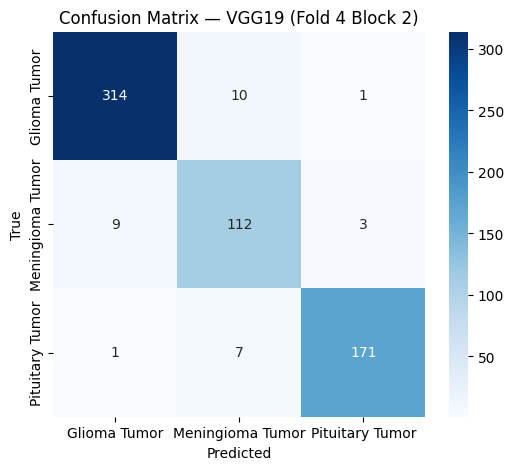

Fold: 4 block 1


Epoch 1/50 | loss: 0.0114 - accuracy: 0.9893 | val_loss: 0.0845 - val_accuracy: 0.9347
val_accuracy improved from 0.0000 to 0.9347, saving weights to /kaggle/working/VGG19_block_1_fold_4.pth


Epoch 2/50 | loss: 0.0099 - accuracy: 0.9860 | val_loss: 0.0694 - val_accuracy: 0.9538
val_accuracy improved from 0.9347 to 0.9538, saving weights to /kaggle/working/VGG19_block_1_fold_4.pth


Epoch 3/50 | loss: 0.0075 - accuracy: 0.9893 | val_loss: 0.1074 - val_accuracy: 0.9395
val_accuracy did not improve from 0.9538


Epoch 4/50 | loss: 0.0076 - accuracy: 0.9906 | val_loss: 0.0762 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9538


Epoch 5/50 | loss: 0.0230 - accuracy: 0.9778 | val_loss: 0.0660 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9538


Epoch 6/50 | loss: 0.0064 - accuracy: 0.9918 | val_loss: 0.0848 - val_accuracy: 0.9268
val_accuracy did not improve from 0.9538


Epoch 7/50 | loss: 0.0047 - accuracy: 0.9934 | val_loss: 0.0653 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9538


Epoch 8/50 | loss: 0.0064 - accuracy: 0.9934 | val_loss: 0.0987 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9538
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.069384  0.953822
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       325
Meningioma Tumor       0.90      0.90      0.90       124
 Pituitary Tumor       0.97      0.95      0.96       179

        accuracy                           0.95       628
       macro avg       0.95      0.94      0.94       628
    weighted avg       0.95      0.95      0.95       628



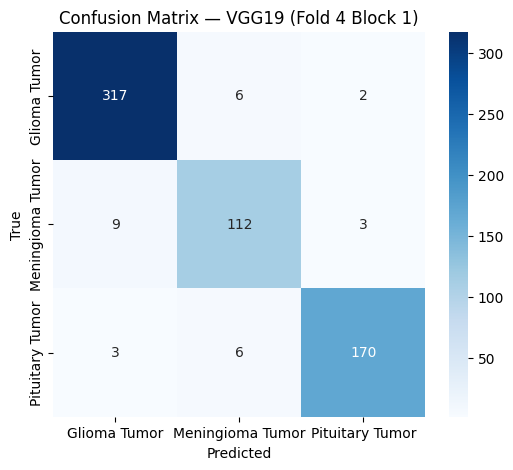

Fold: 5 block 6


Epoch 1/50 | loss: 0.4782 - accuracy: 0.3949 | val_loss: 0.4516 - val_accuracy: 0.4463
val_accuracy improved from 0.0000 to 0.4463, saving weights to /kaggle/working/VGG19_block_6_fold_5.pth


Epoch 2/50 | loss: 0.4283 - accuracy: 0.5188 | val_loss: 0.4172 - val_accuracy: 0.4619
val_accuracy improved from 0.4463 to 0.4619, saving weights to /kaggle/working/VGG19_block_6_fold_5.pth


Epoch 3/50 | loss: 0.3969 - accuracy: 0.5828 | val_loss: 0.3921 - val_accuracy: 0.5412
val_accuracy improved from 0.4619 to 0.5412, saving weights to /kaggle/working/VGG19_block_6_fold_5.pth


Epoch 4/50 | loss: 0.3708 - accuracy: 0.6464 | val_loss: 0.3708 - val_accuracy: 0.5568
val_accuracy improved from 0.5412 to 0.5568, saving weights to /kaggle/working/VGG19_block_6_fold_5.pth


...

Epoch 24/50 | loss: 0.1972 - accuracy: 0.8067 | val_loss: 0.2326 - val_accuracy: 0.7589
val_accuracy did not improve from 0.7621


Epoch 25/50 | loss: 0.2029 - accuracy: 0.7939 | val_loss: 0.2293 - val_accuracy: 0.7589
val_accuracy did not improve from 0.7621


Epoch 26/50 | loss: 0.1934 - accuracy: 0.8166 | val_loss: 0.2330 - val_accuracy: 0.7605
val_accuracy did not improve from 0.7621


Epoch 27/50 | loss: 0.1958 - accuracy: 0.8083 | val_loss: 0.2255 - val_accuracy: 0.7605
val_accuracy did not improve from 0.7621


Epoch 28/50 | loss: 0.1908 - accuracy: 0.8125 | val_loss: 0.2280 - val_accuracy: 0.7589
val_accuracy did not improve from 0.7621
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.237485  0.762053
                  precision    recall  f1-score   support

    Glioma Tumor       0.74      0.90      0.81       287
Meningioma Tumor       0.65      0.40      0.49       166
 Pituitary Tumor       0.86      0.87      0.87       190

        accuracy                           0.76       643
       macro avg       0.75      0.72      0.72       643
    weighted avg       0.75      0.76      0.75       643



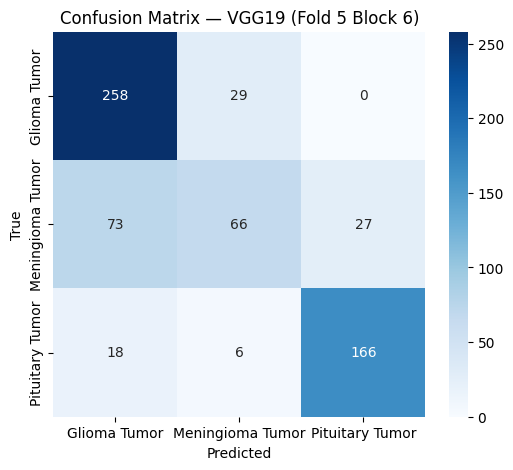

Fold: 5 block 5


Epoch 1/50 | loss: 0.1576 - accuracy: 0.8191 | val_loss: 0.1992 - val_accuracy: 0.7823
val_accuracy improved from 0.0000 to 0.7823, saving weights to /kaggle/working/VGG19_block_5_fold_5.pth


Epoch 2/50 | loss: 0.1143 - accuracy: 0.8653 | val_loss: 0.1953 - val_accuracy: 0.7869
val_accuracy improved from 0.7823 to 0.7869, saving weights to /kaggle/working/VGG19_block_5_fold_5.pth


Epoch 3/50 | loss: 0.1051 - accuracy: 0.8711 | val_loss: 0.1819 - val_accuracy: 0.8072
val_accuracy improved from 0.7869 to 0.8072, saving weights to /kaggle/working/VGG19_block_5_fold_5.pth


Epoch 4/50 | loss: 0.0899 - accuracy: 0.8918 | val_loss: 0.1831 - val_accuracy: 0.8227
val_accuracy improved from 0.8072 to 0.8227, saving weights to /kaggle/working/VGG19_block_5_fold_5.pth


...

Epoch 13/50 | loss: 0.0491 - accuracy: 0.9372 | val_loss: 0.1940 - val_accuracy: 0.8476
val_accuracy did not improve from 0.8600


Epoch 14/50 | loss: 0.0482 - accuracy: 0.9405 | val_loss: 0.1936 - val_accuracy: 0.8538
val_accuracy did not improve from 0.8600


Epoch 15/50 | loss: 0.0533 - accuracy: 0.9356 | val_loss: 0.1939 - val_accuracy: 0.8476
val_accuracy did not improve from 0.8600


Epoch 16/50 | loss: 0.0515 - accuracy: 0.9356 | val_loss: 0.1933 - val_accuracy: 0.8476
val_accuracy did not improve from 0.8600


Epoch 17/50 | loss: 0.0517 - accuracy: 0.9356 | val_loss: 0.1944 - val_accuracy: 0.8476
val_accuracy did not improve from 0.8600
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG19  0.19667  0.860031
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.87      0.90       287
Meningioma Tumor       0.72      0.77      0.74       166
 Pituitary Tumor       0.87      0.93      0.90       190

        accuracy                           0.86       643
       macro avg       0.85      0.85      0.85       643
    weighted avg       0.86      0.86      0.86       643



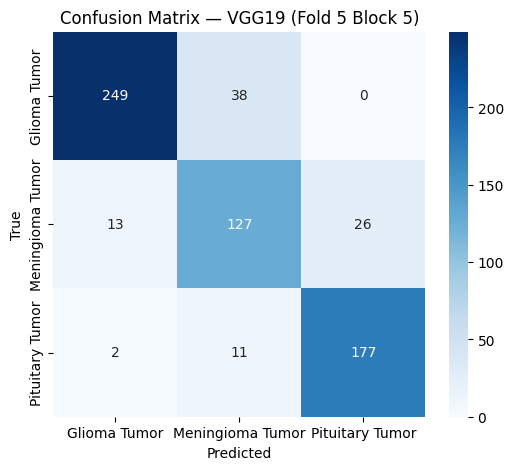

Fold: 5 block 4


Epoch 1/50 | loss: 0.0582 - accuracy: 0.9290 | val_loss: 0.2043 - val_accuracy: 0.8647
val_accuracy improved from 0.0000 to 0.8647, saving weights to /kaggle/working/VGG19_block_4_fold_5.pth


Epoch 2/50 | loss: 0.0479 - accuracy: 0.9426 | val_loss: 0.1895 - val_accuracy: 0.8600
val_accuracy did not improve from 0.8647


Epoch 3/50 | loss: 0.0461 - accuracy: 0.9405 | val_loss: 0.1932 - val_accuracy: 0.8771
val_accuracy improved from 0.8647 to 0.8771, saving weights to /kaggle/working/VGG19_block_4_fold_5.pth


Epoch 4/50 | loss: 0.0397 - accuracy: 0.9496 | val_loss: 0.2205 - val_accuracy: 0.8740
val_accuracy did not improve from 0.8771


...

Epoch 10/50 | loss: 0.0189 - accuracy: 0.9781 | val_loss: 0.2454 - val_accuracy: 0.8787
val_accuracy did not improve from 0.8834


Epoch 11/50 | loss: 0.0184 - accuracy: 0.9765 | val_loss: 0.2315 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8834


Epoch 12/50 | loss: 0.0169 - accuracy: 0.9773 | val_loss: 0.2356 - val_accuracy: 0.8802
val_accuracy did not improve from 0.8834


Epoch 13/50 | loss: 0.0190 - accuracy: 0.9760 | val_loss: 0.2361 - val_accuracy: 0.8818
val_accuracy did not improve from 0.8834


Epoch 14/50 | loss: 0.0171 - accuracy: 0.9773 | val_loss: 0.2363 - val_accuracy: 0.8834
val_accuracy did not improve from 0.8834
early stopping, restoring model weights from the end of the best epoch
   Model     Loss  Accuracy
0  VGG19  0.22172  0.883359
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.89      0.93       287
Meningioma Tumor       0.77      0.79      0.78       166
 Pituitary Tumor       0.88      0.95      0.91       190

        accuracy                           0.88       643
       macro avg       0.87      0.88      0.87       643
    weighted avg       0.89      0.88      0.88       643



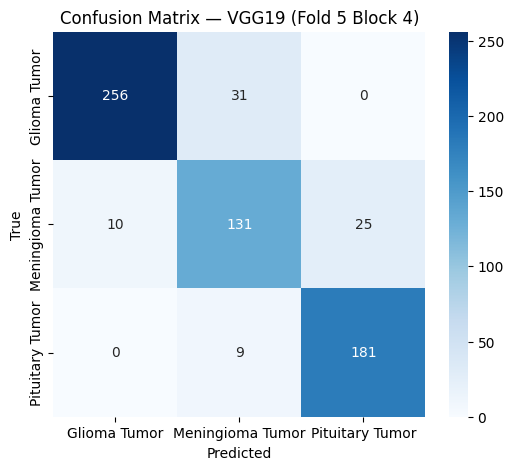

Fold: 5 block 3


Epoch 1/50 | loss: 0.0262 - accuracy: 0.9682 | val_loss: 0.2374 - val_accuracy: 0.8849
val_accuracy improved from 0.0000 to 0.8849, saving weights to /kaggle/working/VGG19_block_3_fold_5.pth


Epoch 2/50 | loss: 0.0250 - accuracy: 0.9674 | val_loss: 0.2464 - val_accuracy: 0.8771
val_accuracy did not improve from 0.8849


Epoch 3/50 | loss: 0.0221 - accuracy: 0.9686 | val_loss: 0.2169 - val_accuracy: 0.9005
val_accuracy improved from 0.8849 to 0.9005, saving weights to /kaggle/working/VGG19_block_3_fold_5.pth


Epoch 4/50 | loss: 0.0183 - accuracy: 0.9769 | val_loss: 0.2844 - val_accuracy: 0.8865
val_accuracy did not improve from 0.9005


...

Epoch 15/50 | loss: 0.0051 - accuracy: 0.9938 | val_loss: 0.2582 - val_accuracy: 0.9005
val_accuracy did not improve from 0.9129


Epoch 16/50 | loss: 0.0058 - accuracy: 0.9946 | val_loss: 0.2593 - val_accuracy: 0.9098
val_accuracy did not improve from 0.9129


Epoch 17/50 | loss: 0.0040 - accuracy: 0.9963 | val_loss: 0.2683 - val_accuracy: 0.9020
val_accuracy did not improve from 0.9129


Epoch 18/50 | loss: 0.0036 - accuracy: 0.9959 | val_loss: 0.2665 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9129


Epoch 19/50 | loss: 0.0035 - accuracy: 0.9955 | val_loss: 0.2666 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9129
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.254064  0.912908
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.94      0.95       287
Meningioma Tumor       0.85      0.81      0.83       166
 Pituitary Tumor       0.88      0.96      0.92       190

        accuracy                           0.91       643
       macro avg       0.90      0.90      0.90       643
    weighted avg       0.91      0.91      0.91       643



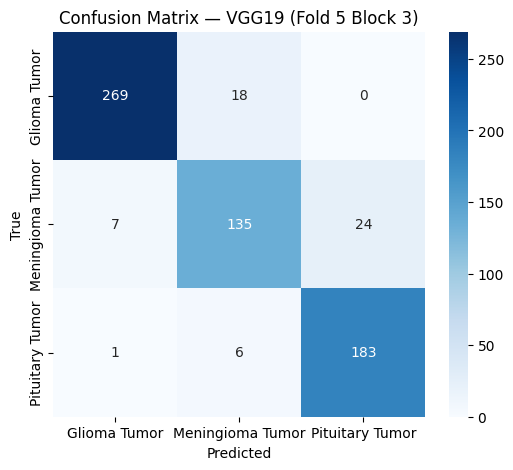

Fold: 5 block 2


Epoch 1/50 | loss: 0.0133 - accuracy: 0.9839 | val_loss: 0.2304 - val_accuracy: 0.9129
val_accuracy improved from 0.0000 to 0.9129, saving weights to /kaggle/working/VGG19_block_2_fold_5.pth


Epoch 2/50 | loss: 0.0065 - accuracy: 0.9917 | val_loss: 0.2903 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9129


Epoch 3/50 | loss: 0.0079 - accuracy: 0.9926 | val_loss: 0.2193 - val_accuracy: 0.9176
val_accuracy improved from 0.9129 to 0.9176, saving weights to /kaggle/working/VGG19_block_2_fold_5.pth


Epoch 4/50 | loss: 0.0135 - accuracy: 0.9802 | val_loss: 0.2952 - val_accuracy: 0.8865
val_accuracy did not improve from 0.9176


Epoch 5/50 | loss: 0.0095 - accuracy: 0.9897 | val_loss: 0.2241 - val_accuracy: 0.9020
val_accuracy did not improve from 0.9176


Epoch 6/50 | loss: 0.0073 - accuracy: 0.9926 | val_loss: 0.2714 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9176


Epoch 7/50 | loss: 0.0070 - accuracy: 0.9901 | val_loss: 0.2865 - val_accuracy: 0.9051
val_accuracy did not improve from 0.9176


Epoch 8/50 | loss: 0.0045 - accuracy: 0.9959 | val_loss: 0.2671 - val_accuracy: 0.9176
val_accuracy did not improve from 0.9176


Epoch 9/50 | loss: 0.0043 - accuracy: 0.9955 | val_loss: 0.2906 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9176
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.219343  0.917574
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.97      0.96       287
Meningioma Tumor       0.86      0.83      0.84       166
 Pituitary Tumor       0.90      0.92      0.91       190

        accuracy                           0.92       643
       macro avg       0.91      0.90      0.91       643
    weighted avg       0.92      0.92      0.92       643



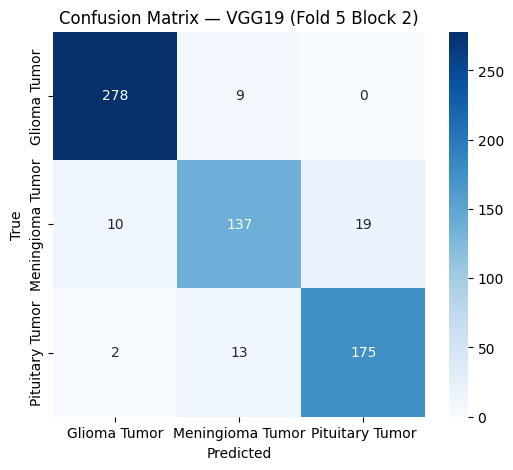

Fold: 5 block 1


Epoch 1/50 | loss: 0.0144 - accuracy: 0.9835 | val_loss: 0.2248 - val_accuracy: 0.9191
val_accuracy improved from 0.0000 to 0.9191, saving weights to /kaggle/working/VGG19_block_1_fold_5.pth


Epoch 2/50 | loss: 0.0094 - accuracy: 0.9897 | val_loss: 0.2747 - val_accuracy: 0.8942
val_accuracy did not improve from 0.9191


Epoch 3/50 | loss: 0.0061 - accuracy: 0.9930 | val_loss: 0.2909 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9191


Epoch 4/50 | loss: 0.0086 - accuracy: 0.9901 | val_loss: 0.3266 - val_accuracy: 0.8974
val_accuracy did not improve from 0.9191


...

Epoch 7/50 | loss: 0.0030 - accuracy: 0.9963 | val_loss: 0.3094 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9207


Epoch 8/50 | loss: 0.0018 - accuracy: 0.9983 | val_loss: 0.3493 - val_accuracy: 0.9098
val_accuracy did not improve from 0.9207


Epoch 9/50 | loss: 0.0024 - accuracy: 0.9971 | val_loss: 0.3602 - val_accuracy: 0.9098
val_accuracy did not improve from 0.9207


Epoch 10/50 | loss: 0.0031 - accuracy: 0.9959 | val_loss: 0.3170 - val_accuracy: 0.9160
val_accuracy did not improve from 0.9207


Epoch 11/50 | loss: 0.0024 - accuracy: 0.9975 | val_loss: 0.3275 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9207
early stopping, restoring model weights from the end of the best epoch
   Model      Loss  Accuracy
0  VGG19  0.288259  0.920684
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.95      0.96       287
Meningioma Tumor       0.88      0.83      0.85       166
 Pituitary Tumor       0.88      0.96      0.92       190

        accuracy                           0.92       643
       macro avg       0.91      0.91      0.91       643
    weighted avg       0.92      0.92      0.92       643



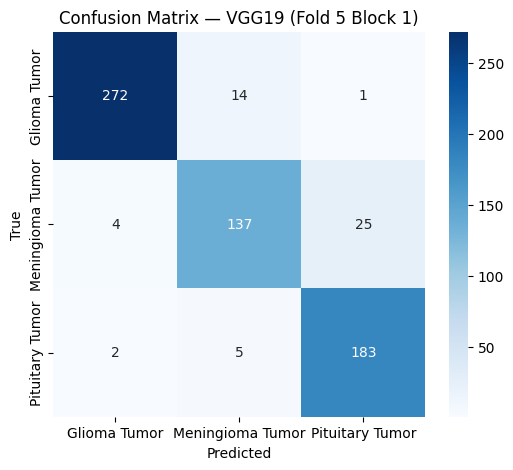

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5, acc_b6 = [], [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b6.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 80.96%
Accuracy unfreeze block 5 - block 6: 89.71%
Accuracy unfreeze block 4 - block 6: 92.09%
Accuracy unfreeze block 3 - block 6: 93.52%
Accuracy unfreeze block 2 - block 6: 93.75%
Accuracy unfreeze block 1 - block 6: 94.08%
